原始文字: happy good 轉換後的 Token_ids: [28, 30]
訓練資料數: 16
Epoch 0, Loss: 0.6994386428339039
Epoch 10, Loss: 0.6994466704304858
Epoch 20, Loss: 0.699436290415389
Epoch 30, Loss: 0.6993968891044366
Epoch 40, Loss: 0.6992797446317393
Epoch 50, Loss: 0.6989342039081747
Epoch 60, Loss: 0.6979172891490899
Epoch 70, Loss: 0.6949450877966221
Epoch 80, Loss: 0.6864323816137272
Epoch 90, Loss: 0.6634173955346383
Epoch 100, Loss: 0.6099363107385934
Epoch 110, Loss: 0.5198448493068343
Epoch 120, Loss: 0.4230023732141198
Epoch 130, Loss: 0.34895260993076654
Epoch 140, Loss: 0.2977786241771782
Epoch 150, Loss: 0.26098471170252113
Epoch 160, Loss: 0.23262795337187214
Epoch 170, Loss: 0.20945343960503346
Epoch 180, Loss: 0.18970734692331057
Epoch 190, Loss: 0.17241239214259663
Epoch 200, Loss: 0.1570025961162312
Epoch 210, Loss: 0.1431381777991301
Epoch 220, Loss: 0.13060597829436632
Epoch 230, Loss: 0.11926254512870071
Epoch 240, Loss: 0.10900080606396065
Epoch 250, Loss: 0.09973115850868466
Epoch 260, Los

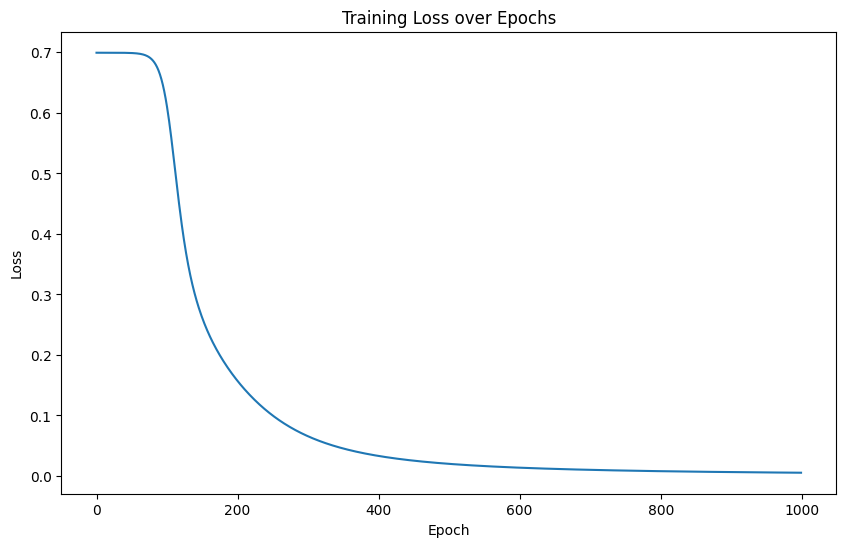

負面 4.243516915254138e-06


In [12]:
import numpy as np 

texts = [
    "happy good", "sad bad", "excellent happy", "terrible sad",
    "wonderful great", "awful poor", "good wonderful", "bad awful",
    "amazing fantastic", "horrible dreadful", "pleasant delightful", "unpleasant miserable",
    "lovely amazing", "disgusting horrible", "fantastic wonderful", "dreadful awful"
]
y = np.array([[1], [0], [1], [0], [1], [0], [1], [0], [1], [0], [1], [0], [1], [0], [1], [0]])

from tokenizer import BPE 
from collections import Counter 

# Cut each word 
tokens = [token for text in texts for token in text.split()]
vocab = Counter(tokens) 

# Initialize BPE
tokenizer = BPE(vocab)
bpe_tokens = tokenizer.bpe_iterate(30)
x = [tokenizer(text) for text in texts]

# Test result
print(f"原始文字: {texts[0]} 轉換後的 Token_ids: {tokenizer(texts[0])}")
print(f"訓練資料數: {len(x)}")

# 手刻 NLP 模型
class SentimentModel:
    def __init__(self, vocab_size, embed_dim, output_dim):
        """
        embed_dim : 詞嵌入的維度 (每個詞用多少維的向量表示)
        output_dim : 輸出的類別數 (例如正面 / 負面 -> 2) 
        """
        # 初始化詞嵌入層 E 
        self.embedding_matrix = np.random.randn(vocab_size, embed_dim) * 0.01
        # To each word (total vocab_size) will generate a vector (length is embed_dim)
        
        # 初始化線性分類器權重 w 和偏移量 b 
        self.W = np.random.randn(embed_dim, output_dim) * 0.01
        self.b = np.zeros(output_dim)
    
    # Define activation function
    def sigmoid(self, z):
        return 1 / (1 + np.exp(-z)) # predict output 
    
    def binary_cross_entropy_loss(self, y_hat, y):
        epsilon = 1e-15 # 加入一個微小數值防止 log(0)
        y_hat = np.clip(y_hat, epsilon, 1 - epsilon)
        return -np.sum(y * np.log(y_hat) + (1 - y) * np.log(1 - y_hat)) # 回傳損失值
    
    def forward(self, word_indices, y):
        # 將 Token 轉換成嵌入層特徵
        word_embeddings = self.embedding_matrix[word_indices]
        # calcualte sentence vector
        sentence_vector = np.mean(word_embeddings, axis=0)
        # 線性分類器輸出
        z = np.dot(sentence_vector, self.W) + self.b # Z = s x W + b
        # 預測輸出 (公式 2.4)
        y_hat = self.sigmoid(z)

        # 回傳損失值與預測值
        return self.binary_cross_entropy_loss(y_hat, y), y_hat
    
    def backward(self, word_indices, y_hat, y, learning_rate):
        # 線性分類器對於損失值的梯度
        dz = y_hat - y 
        # 計算平均向量
        sentence_vector = np.mean(self.embedding_matrix[word_indices], axis=0)
        # 權重的梯度
        dW = np.outer(sentence_vector, dz)
        # 偏移量的梯度
        db = dz 

        # 句子向量的梯度
        ds = np.dot(dz, self.W.T)

        # 每個 token 詞嵌入梯度
        de = ds/ len(word_indices)
        # 用於儲存每個 token 的梯度
        dE = np.zeros_like(self.embedding_matrix)
        # 累積梯度 (公式2.17)
        np.add.at(dE, word_indices, de) 

        # 梯度下降法 (公式2.18)
        self.W -= learning_rate * dW
        self.b -= learning_rate * db
        self.embedding_matrix -= learning_rate * dE
    
    def predict(self, x):
        # 只需要計算機率值因此可以隨便傳入數字
        _, pred = self.forward(x, 0)
        # 輸出類別與機率值
        return "正面" if pred > 0.5 else "負面", pred[0]
    
# Usually Embedding layer = Tokenzer 中的 token 量
vocab_size = len(tokenizer.tokens)
embed_dim = 2
output_dim = 1 
model = SentimentModel(vocab_size, embed_dim, output_dim)

def train(x, y, model, epochs=20, learning_rate=0.01):
    history = []
    for epoch in range(epochs):
        total_loss = 0
        for token_ids, label in zip(x, y):
            # train model 
            loss, y_hat = model.forward(token_ids, label)                   # Forward propagation
            model.backward(token_ids, y_hat, label, learning_rate)   # Backword propagation
            total_loss += loss 
        avg_loss = total_loss / len(texts) # calculate average loss
        history.append(avg_loss)           # record average loss

        if epoch % 10 == 0:
            print(f"Epoch {epoch}, Loss: {avg_loss}")
    
    return history 

history = train(x, y, model, epochs=1000, learning_rate=0.05)

import matplotlib.pyplot as plt

def visualize_training(losses):
    plt.figure(figsize=(10, 6))
    plt.plot(losses)
    plt.title('Training Loss over Epochs')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.show()

visualize_training(history)

token_ids = tokenizer('horrible')
sentiment, score = model.predict(token_ids)
print(sentiment, score)